# Phase 2 — Data Acquisition & Exploration

**Course**: CS5143 Natural Language Processing — Spring 2026, FAST-NUCES  
**Student**: Muhammad Azhar (24K-7606)

This notebook loads the MultiClinAI clinical NER dataset for English and Spanish,
produces summary statistics, and visualizes entity distributions to inform the
preprocessing and training decisions in later phases.

**Prerequisites**: Place CoNLL files at `data/raw/en/` and `data/raw/es/` before running.
See `data/raw/README.md` for download instructions.

## 1. Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src') if os.path.basename(os.getcwd()) == 'notebooks' else 'src')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from dataset import load_conll, entity_counts, LABEL_LIST, label2id

# Resolve paths relative to repo root regardless of where notebook is launched
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '')) \
    if os.path.basename(os.getcwd()) == 'notebooks' \
    else os.getcwd()
DATA_DIR   = os.path.join(REPO_ROOT, 'data', 'raw')
OUTPUT_DIR = os.path.join(REPO_ROOT, 'outputs', 'results')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Repo root : {REPO_ROOT}')
print(f'Data dir  : {DATA_DIR}')
print(f'Output dir: {OUTPUT_DIR}')
print(f'Labels    : {LABEL_LIST}')

Repo root : /home/azharthegeek/Desktop/work/MultiClinNER-XLMR
Data dir  : /home/azharthegeek/Desktop/work/MultiClinNER-XLMR/data/raw
Output dir: /home/azharthegeek/Desktop/work/MultiClinNER-XLMR/outputs/results
Labels    : ['O', 'B-DIS', 'I-DIS', 'B-SYM', 'I-SYM', 'B-PRO', 'I-PRO']


## 2. Load All Splits

We load train, dev, and test CoNLL files for both English and Spanish.
Each split is a Python list of sentence dicts: `{"tokens": [...], "ner_tags": [...]}`.

In [2]:
def load_split(lang, split):
    path = os.path.join(DATA_DIR, lang, f'{split}.conll')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'Missing: {path}\n'
            f'Please download the MultiClinAI dataset and place files under data/raw/'
        )
    return load_conll(path)

en_train = load_split('en', 'train')
en_dev   = load_split('en', 'dev')
en_test  = load_split('en', 'test')
es_train = load_split('es', 'train')
es_dev   = load_split('es', 'dev')
es_test  = load_split('es', 'test')

print('All splits loaded successfully.')

All splits loaded successfully.


## 3. Dataset Statistics

Count sentences, tokens, and entities per split and language.
This table is the reference for the statistics section in CLAUDE.md.

In [3]:
rows = []
for name, split in [
    ('EN  train', en_train), ('EN  dev',   en_dev),   ('EN  test',  en_test),
    ('ES  train', es_train), ('ES  dev',   es_dev),   ('ES  test',  es_test),
]:
    counts = entity_counts(split)
    rows.append({
        'Split':     name,
        'Sentences': len(split),
        'Tokens':    sum(len(s['tokens']) for s in split),
        'DIS':       counts.get('DIS', 0),
        'SYM':       counts.get('SYM', 0),
        'PRO':       counts.get('PRO', 0),
    })

stats_df = pd.DataFrame(rows)
stats_df['Total entities'] = stats_df['DIS'] + stats_df['SYM'] + stats_df['PRO']
stats_df

,Split,Sentences,Tokens,DIS,SYM,PRO,Total entities
0,EN train,10000,1450485,16341,19177,19261,54779
1,EN dev,2315,316110,4121,4237,3539,11897
2,EN test,2250,316342,4499,4029,3832,12360
3,ES train,10163,1502945,18243,20512,19268,58023
4,ES dev,2151,330275,3921,4904,4198,13023
5,ES test,2251,328565,4063,3650,4637,12350


## 4. Entity Distribution Charts

Bar charts showing the count of each entity type in the training set for both languages.
A large imbalance between entity types (e.g., many DIS but few PRO) may require
class-weighted loss or over-sampling in training.

Saved: /home/azharthegeek/Desktop/work/MultiClinNER-XLMR/outputs/results/entity_distribution.png


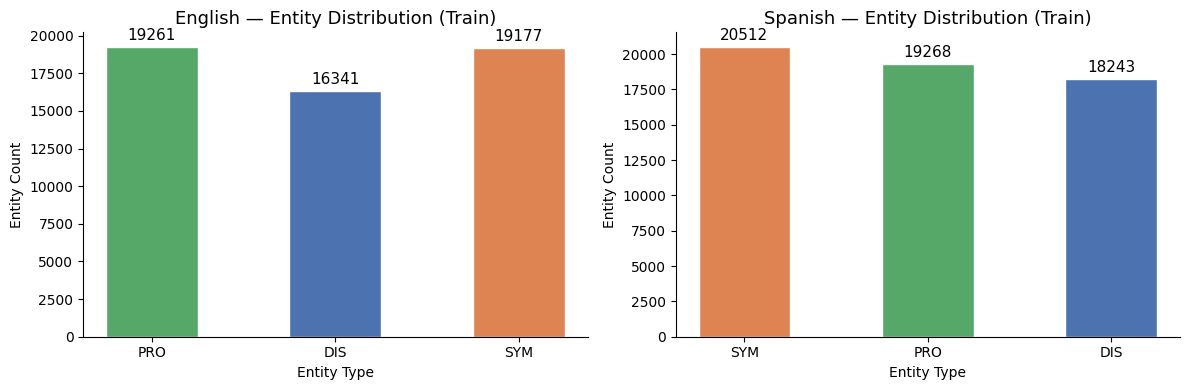

In [4]:
COLORS = {'DIS': '#4C72B0', 'SYM': '#DD8452', 'PRO': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lang_name, train_split) in zip(axes, [('English', en_train), ('Spanish', es_train)]):
    c = entity_counts(train_split)
    entity_types = list(c.keys())
    bars = ax.bar(
        entity_types,
        [c[e] for e in entity_types],
        color=[COLORS.get(e, '#999') for e in entity_types],
        width=0.5,
        edgecolor='white',
    )
    ax.bar_label(bars, padding=3, fontsize=11)
    ax.set_title(f'{lang_name} — Entity Distribution (Train)', fontsize=13)
    ax.set_ylabel('Entity Count')
    ax.set_xlabel('Entity Type')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'entity_distribution.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## 5. Sample Sentence Display

Display annotated sample sentences to visually verify the CoNLL format loaded correctly.
Entity spans are highlighted with their type labels inline.

In [5]:
def display_sentence(s, show_o=True):
    """Print a sentence with entity tags shown inline."""
    parts = []
    for tok, tag in zip(s['tokens'], s['ner_tags']):
        if tag == 'O':
            parts.append(tok)
        else:
            parts.append(f'[{tok}|{tag}]')
    print(' '.join(parts))


def find_sentence_with_entity(splits, entity_type='DIS'):
    """Return the first sentence that contains the given entity type."""
    for s in splits:
        if any(tag == f'B-{entity_type}' for tag in s['ner_tags']):
            return s
    return splits[0]


print('=== English sample (with a Disease entity) ===')
display_sentence(find_sentence_with_entity(en_train, 'DIS'))

print()
print('=== Spanish sample (with a Symptom entity) ===')
display_sentence(find_sentence_with_entity(es_train, 'SYM'))

print()
print('=== English sample (with a Procedure entity) ===')
display_sentence(find_sentence_with_entity(en_train, 'PRO'))

=== English sample (with a Disease entity) ===
A 5-year-old boy with an unremarkable personal history and adequate paediatric control. The parents only emphasised that he was a child who did not eat much. A week before the incident, he presented with an [upper|B-DIS] [respiratory|I-DIS] [tract|I-DIS] [cold|I-DIS] without fever or other associated signs. The parents report that he also presented non-specific abdominal discomfort, accompanied by increased bowel sounds and nausea without vomiting. He was assessed by his local paediatrician, who found no specific pathology and prescribed a soft diet. At 0 hours on the day of death, the child woke up with unfocused abdominal pain. Over the next few hours, he felt nauseous and had several episodes of vomiting, first of food and finally mucous vomiting with no hematic or bilious traces. At 5 a.m., he was found to be weak and cold and was given a hot bath, and in the bath he was found to be unresponsive to stimuli. The assistance of an emergen

## 6. Token Length Distribution

Check the distribution of sentence lengths (in tokens) to confirm our choice of
`max_length=128` in the tokenizer covers the vast majority of sentences without truncation.

Saved: /home/azharthegeek/Desktop/work/MultiClinNER-XLMR/outputs/results/sentence_length_distribution.png


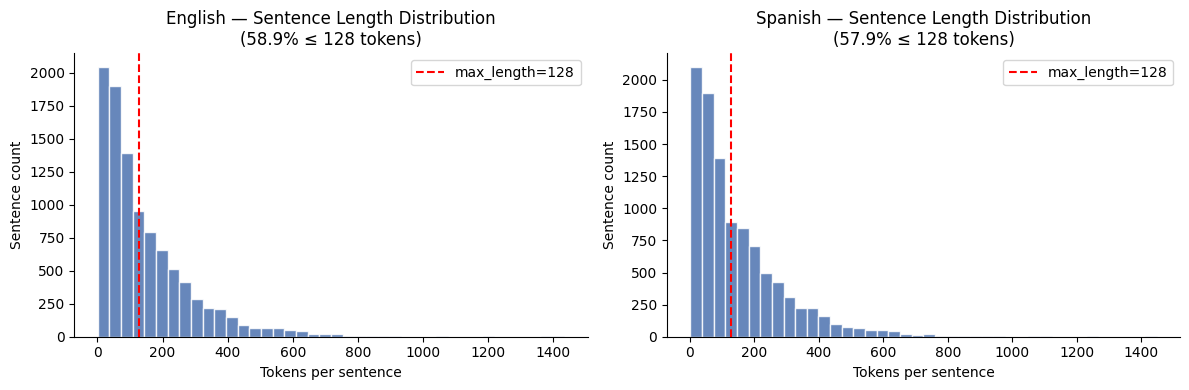

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lang_name, train_split) in zip(axes, [('English', en_train), ('Spanish', es_train)]):
    lengths = [len(s['tokens']) for s in train_split]
    ax.hist(lengths, bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(128, color='red', linestyle='--', linewidth=1.5, label='max_length=128')
    pct_covered = sum(l <= 128 for l in lengths) / len(lengths) * 100
    ax.set_title(f'{lang_name} — Sentence Length Distribution\n({pct_covered:.1f}% ≤ 128 tokens)', fontsize=12)
    ax.set_xlabel('Tokens per sentence')
    ax.set_ylabel('Sentence count')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, 'sentence_length_distribution.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## Summary

**What we learned from EDA:**
- Dataset sizes and entity counts are documented in the statistics table above
- Entity type distribution shows whether class imbalance needs to be addressed
- Sentence length distribution confirms `max_length=128` is appropriate (update if not)

**Next step**: Phase 3 — Preprocessing Pipeline (`notebooks/02_preprocessing.ipynb`)